## Setup

In [2]:
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
BASE_DIR = os.path.join(PROJECT_ROOT, "data")

MULTI_NAME = "potiN2tupiN1"
SINGLE_NAME = "infer_vllm_778989"

MULTI_PATH = os.path.join(BASE_DIR, MULTI_NAME)
SINGLE_PATH = os.path.join(BASE_DIR, SINGLE_NAME)

print("MULTI_PATH:", MULTI_PATH)
print("SINGLE_PATH:", SINGLE_PATH)

MULTI_PATH: /home/rafael/Documents/comp-sys-perf-analysis/data/potiN2tupiN1
SINGLE_PATH: /home/rafael/Documents/comp-sys-perf-analysis/data/infer_vllm_778989


In [3]:
experiment_folders = []

# multi-experiment group
if os.path.exists(MULTI_PATH):
    experiment_folders += [
        entry.path for entry in os.scandir(MULTI_PATH) if entry.is_dir()
    ]

# single experiment (already a full experiment folder)
if os.path.exists(SINGLE_PATH):
    experiment_folders.append(SINGLE_PATH)

print("Total experiments:", len(experiment_folders))

Total experiments: 7


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_telemetry_files(experiment_path):
    telemetry_files = []

    for root, _, files in os.walk(experiment_path):
        if 'telemetry.csv' in files:
            telemetry_files.append(os.path.join(root, 'telemetry.csv'))

    return telemetry_files

def plot_gpu_utilization_for_experiment(experiment_path):
    experiment_name = os.path.basename(experiment_path)

    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names (IMPORTANT)
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns or 'utilization.gpu [%]' not in df.columns:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            # Label by node (folder name: poti1, poti5, tupi6, etc.)
            node_name = os.path.basename(os.path.dirname(file_path))

            plt.plot(
                df['timestamp'],
                df['utilization.gpu [%]'],
                label=node_name
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    plt.title(f'GPU Utilization - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('GPU Utilization (%)')
    plt.legend(title='Node')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [6]:
def plot_gpu_memory_usage(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]

        if 'timestamp' not in df.columns or 'memory.used [MiB]' not in df.columns:
            continue

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')

        node_name = os.path.basename(os.path.dirname(file_path))

        plt.plot(
            df['timestamp'],
            df['memory.used [MiB]'],
            label=node_name
        )

    plt.title(f'GPU Memory Usage - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Memory Used (MiB)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [7]:
def plot_gpu_power(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        df = pd.read_csv(file_path)
        df.columns = [c.strip() for c in df.columns]

        if 'timestamp' not in df.columns or 'power.draw [W]' not in df.columns:
            continue

        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp')

        node_name = os.path.basename(os.path.dirname(file_path))

        plt.plot(
            df['timestamp'],
            df['power.draw [W]'],
            label=node_name
        )

    plt.title(f'GPU Power Draw - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Power (W)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

In [10]:
def plot_gpu_temperature(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    plt.figure(figsize=(15, 6))

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns:
                continue

            # Handle possible temperature column variations
            temp_col = None
            for candidate in ['temperature.gpu', 'temperature.gpu [C]', 'temperature.gpu [°C]']:
                if candidate in df.columns:
                    temp_col = candidate
                    break

            if temp_col is None:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            node_name = os.path.basename(os.path.dirname(file_path))

            plt.plot(
                df['timestamp'],
                df[temp_col],
                label=node_name
            )

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    plt.title(f'GPU Temperature - {experiment_name}')
    plt.xlabel('Time')
    plt.ylabel('Temperature (°C)')
    plt.legend(title='Node')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

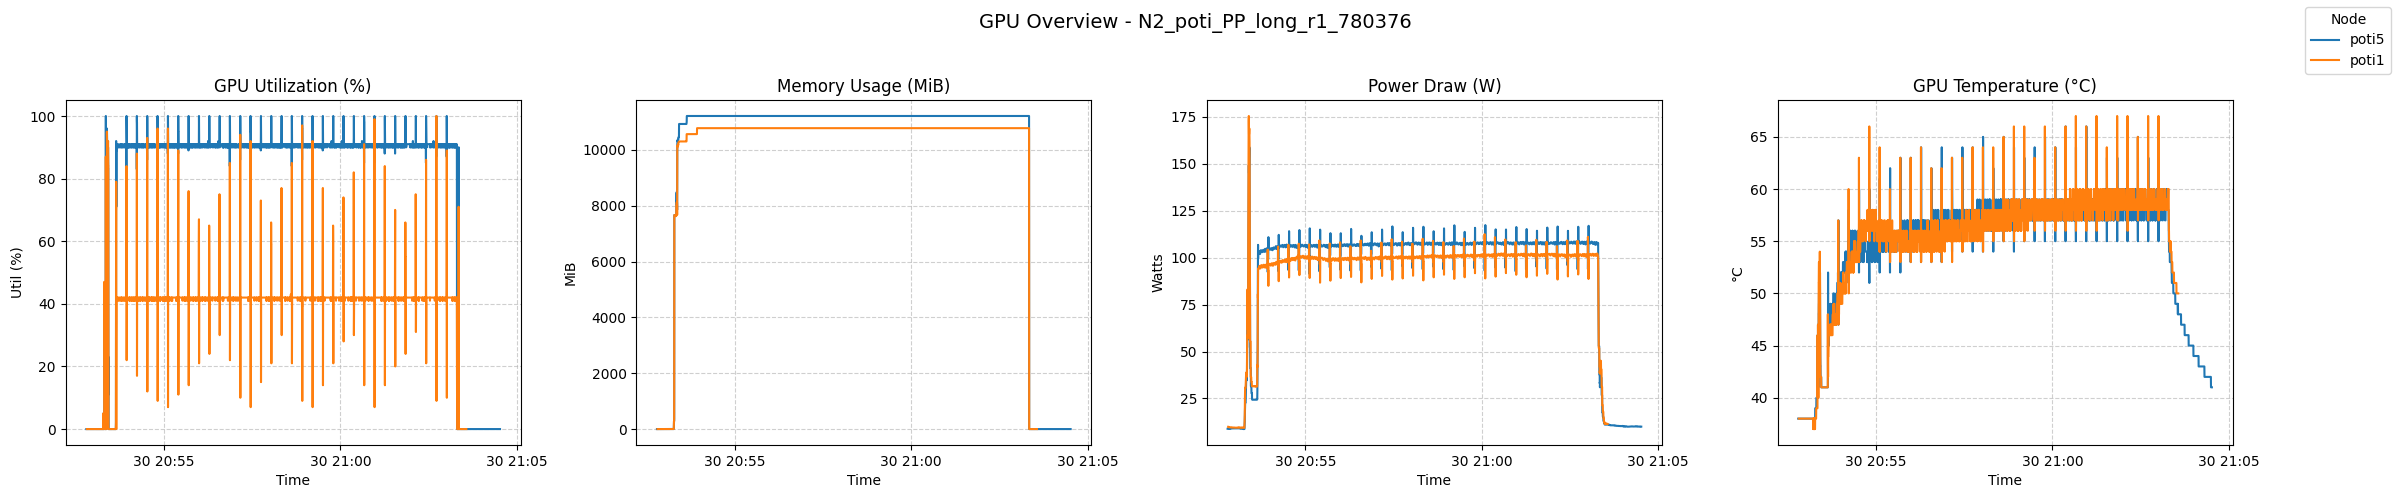

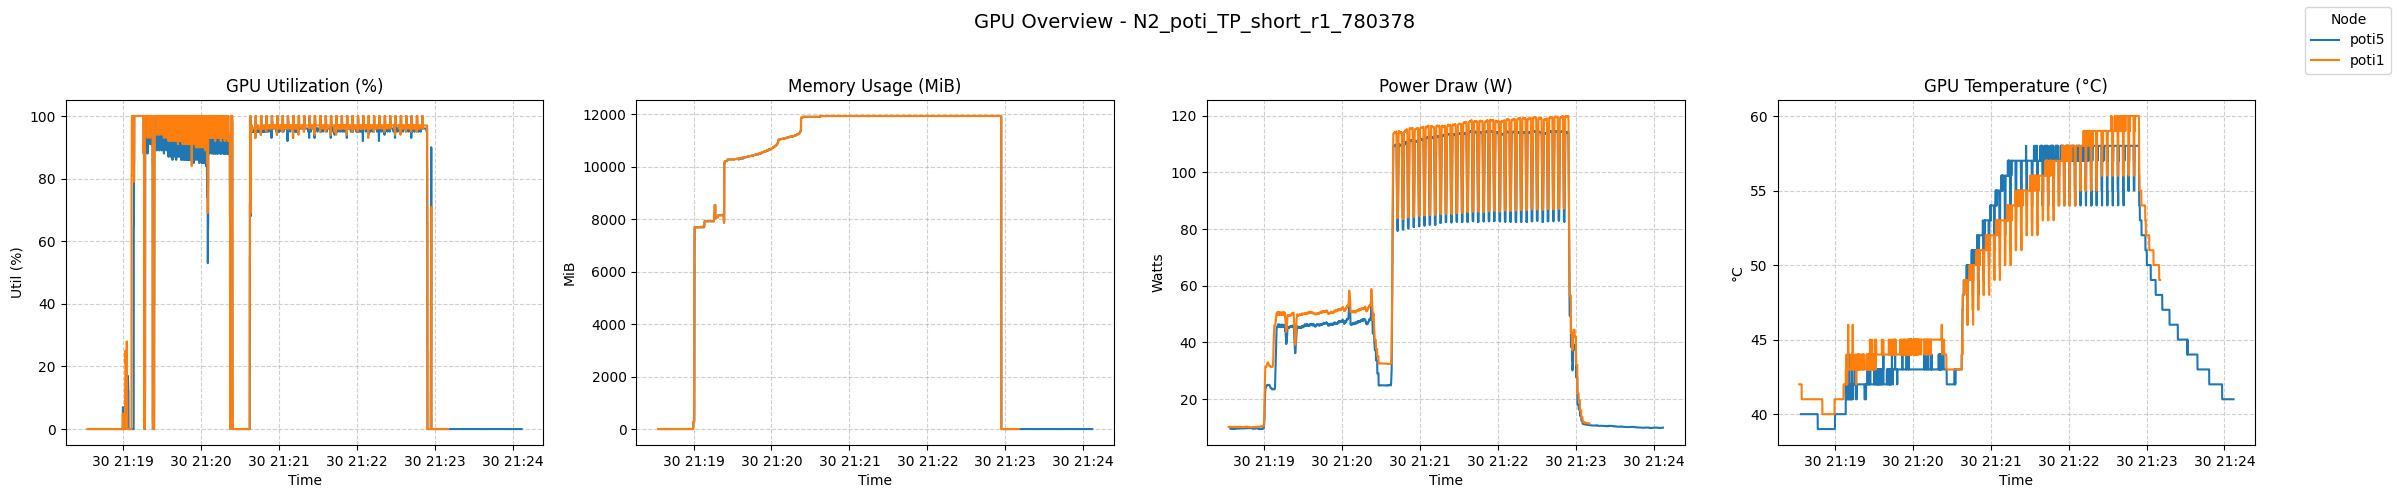

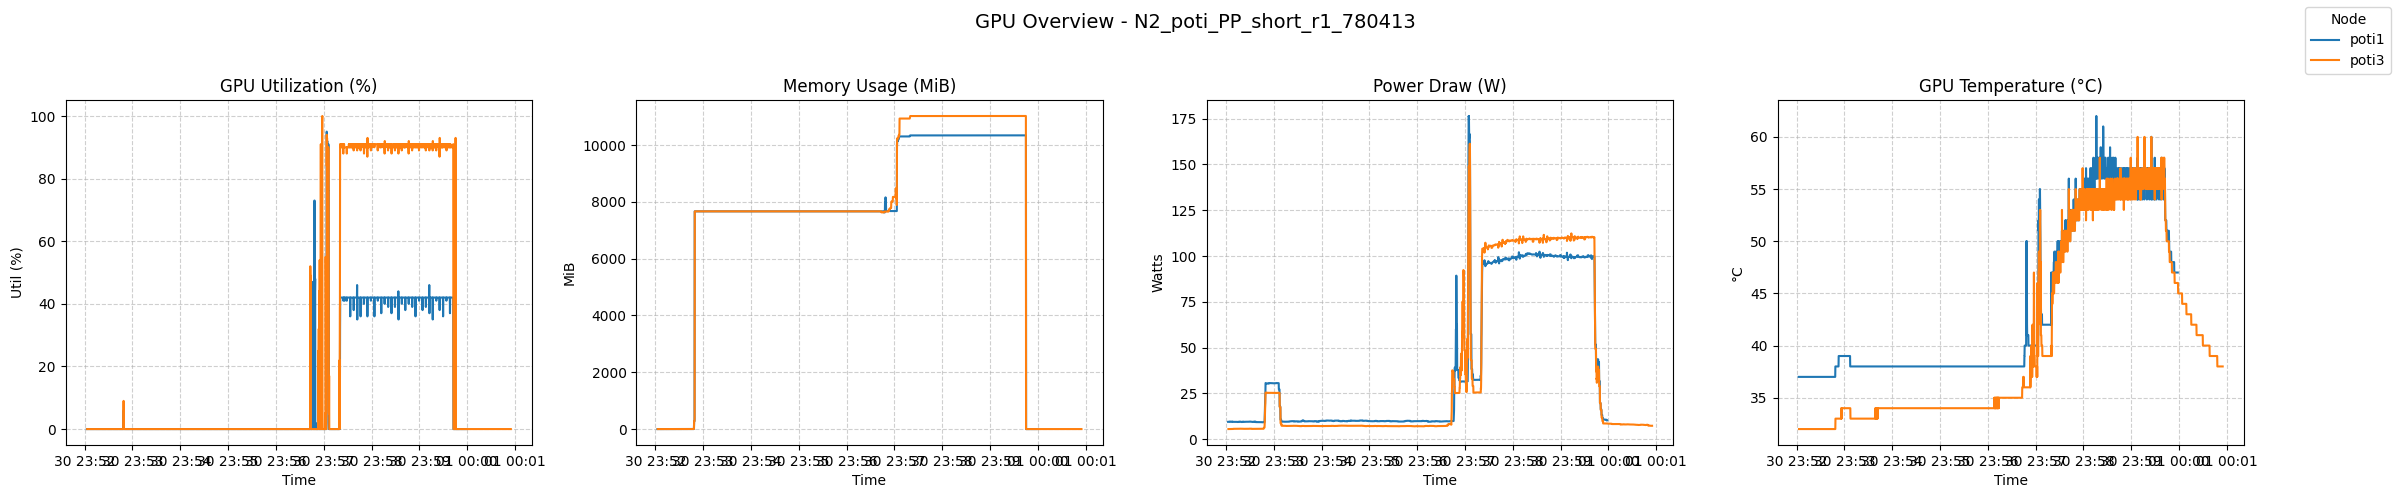

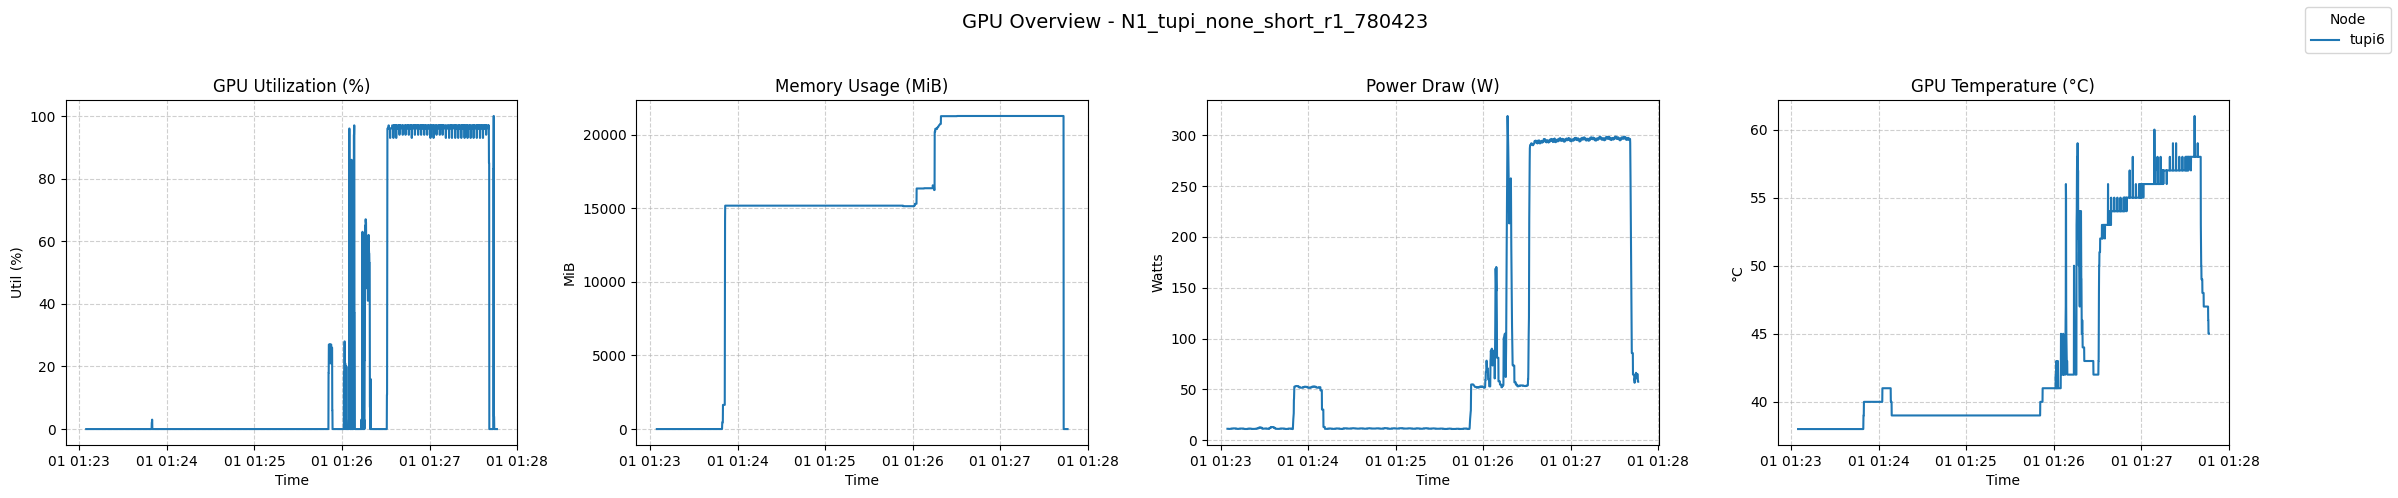

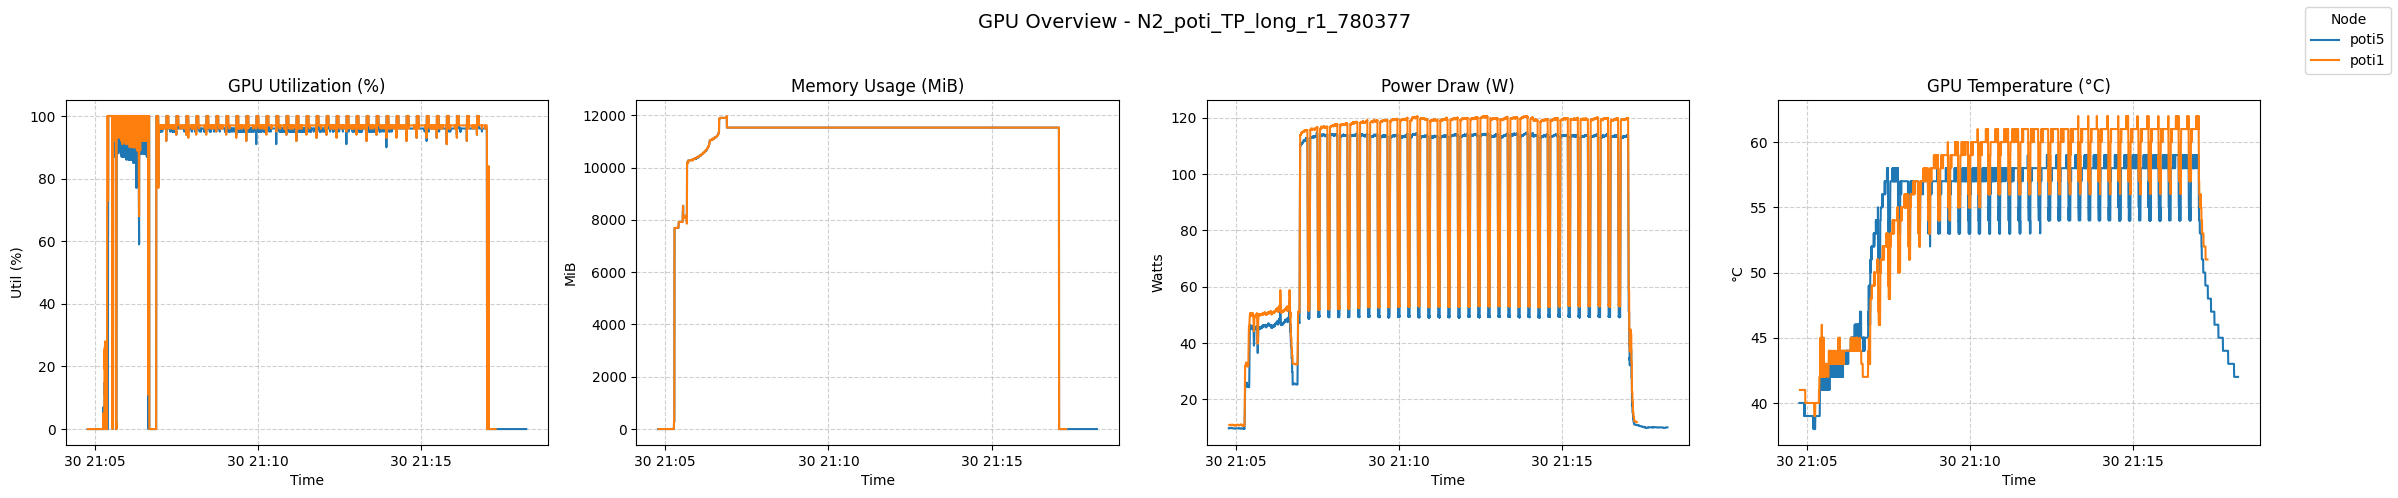

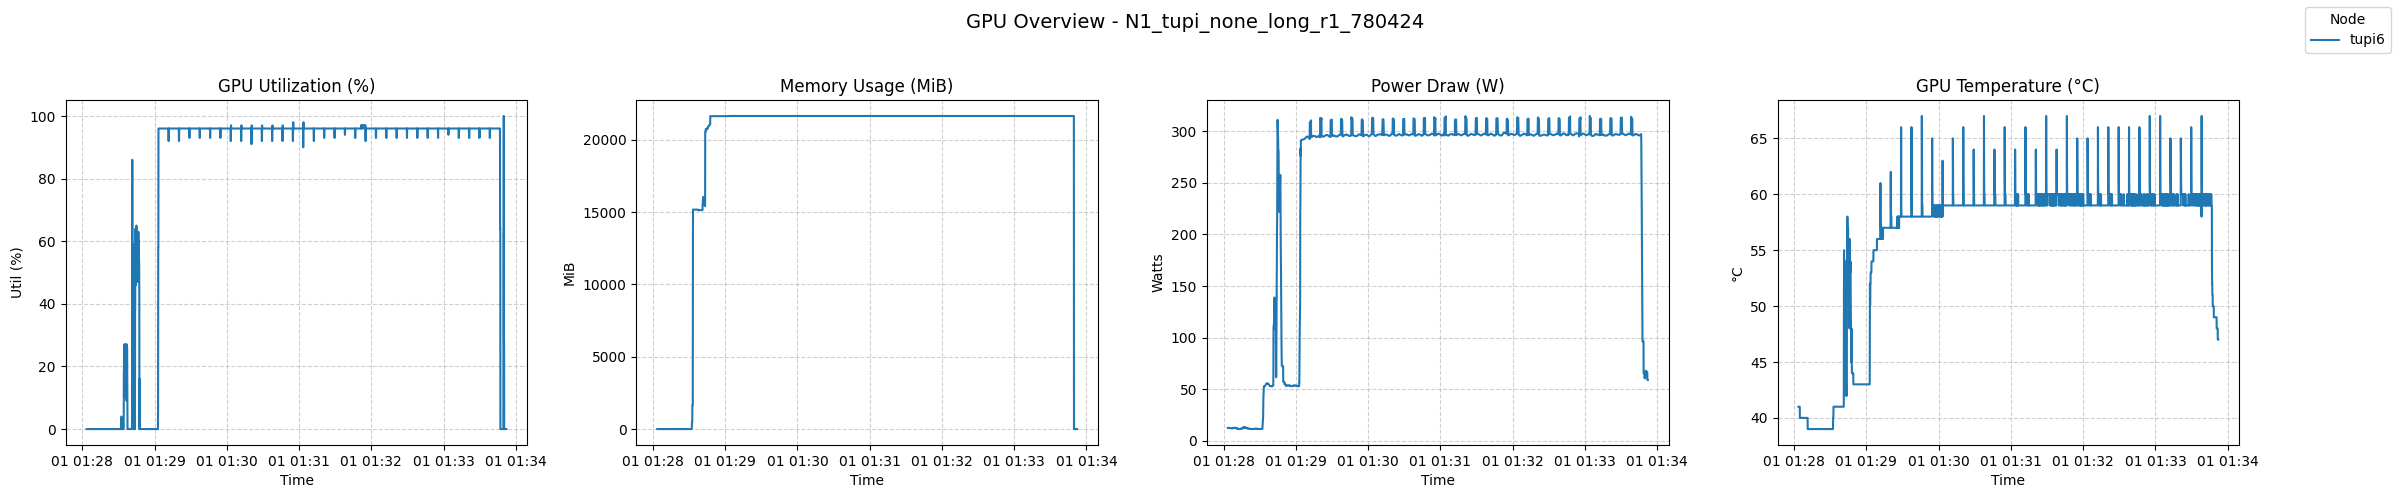

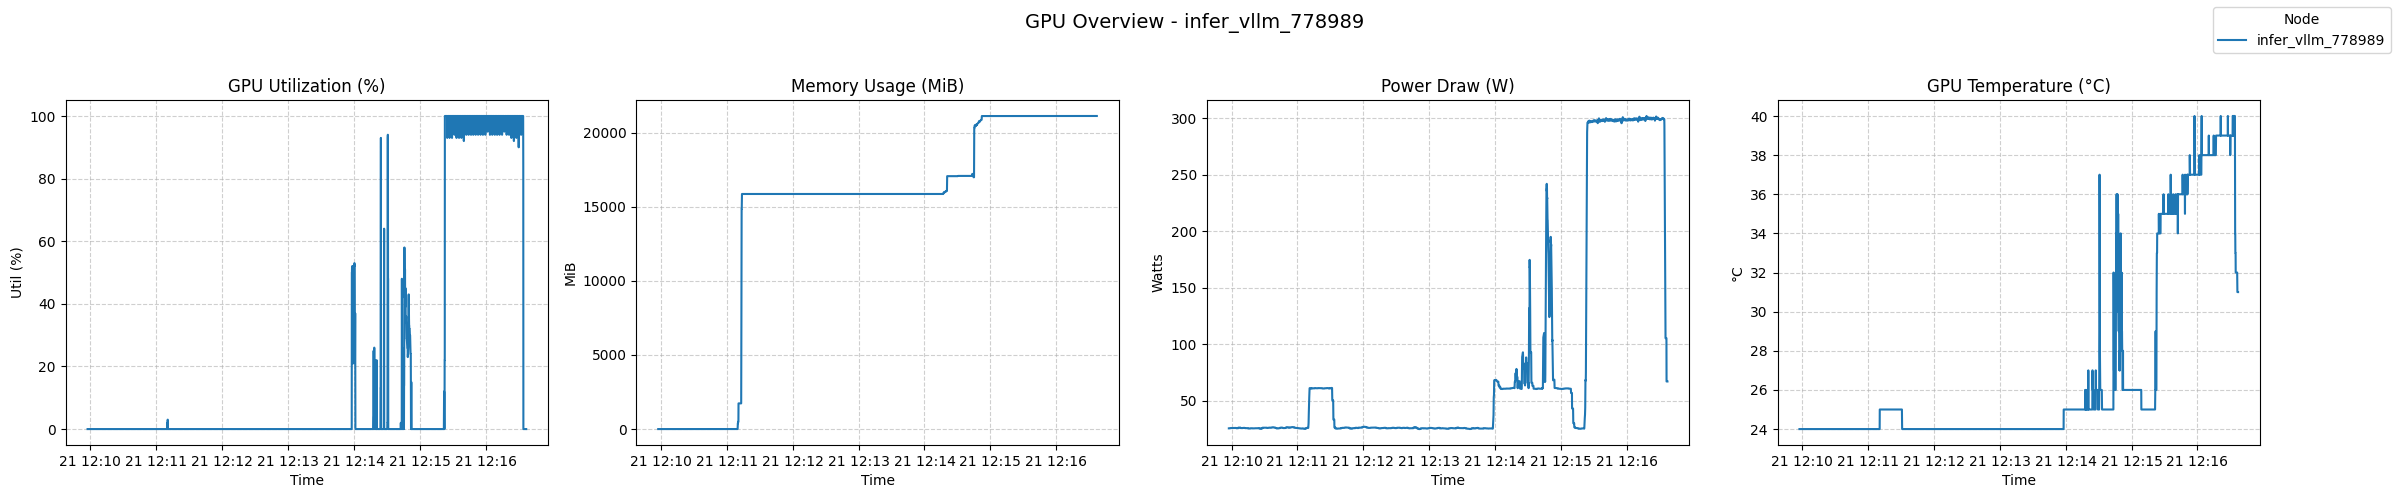

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

def find_telemetry_files(experiment_path):
    telemetry_files = []

    for root, _, files in os.walk(experiment_path):
        if 'telemetry.csv' in files:
            telemetry_files.append(os.path.join(root, 'telemetry.csv'))

    return telemetry_files


def plot_gpu_overview(experiment_path):
    experiment_name = os.path.basename(experiment_path)
    telemetry_files = find_telemetry_files(experiment_path)

    if not telemetry_files:
        print(f"No telemetry found for {experiment_name}")
        return

    # ===== NOW 4 PLOTS =====
    fig, axes = plt.subplots(1, 4, figsize=(24, 5), sharex=True)

    ax_util, ax_mem, ax_power, ax_temp = axes

    for file_path in telemetry_files:
        try:
            df = pd.read_csv(file_path)

            # Clean column names
            df.columns = [c.strip() for c in df.columns]

            if 'timestamp' not in df.columns:
                continue

            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.sort_values('timestamp')

            node_name = os.path.basename(os.path.dirname(file_path))

            # ===== GPU UTIL =====
            if 'utilization.gpu [%]' in df.columns:
                ax_util.plot(df['timestamp'], df['utilization.gpu [%]'], label=node_name)

            # ===== MEMORY =====
            if 'memory.used [MiB]' in df.columns:
                ax_mem.plot(df['timestamp'], df['memory.used [MiB]'], label=node_name)

            # ===== POWER =====
            if 'power.draw [W]' in df.columns:
                ax_power.plot(df['timestamp'], df['power.draw [W]'], label=node_name)

            # ===== TEMPERATURE =====
            if 'temperature.gpu' in df.columns:
                ax_temp.plot(df['timestamp'], df['temperature.gpu'], label=node_name)

        except Exception as e:
            print(f"Error reading {file_path}: {e}")

    # ===== TITLES =====
    ax_util.set_title('GPU Utilization (%)')
    ax_mem.set_title('Memory Usage (MiB)')
    ax_power.set_title('Power Draw (W)')
    ax_temp.set_title('GPU Temperature (°C)')

    # ===== LABELS =====
    ax_util.set_ylabel('Util (%)')
    ax_mem.set_ylabel('MiB')
    ax_power.set_ylabel('Watts')
    ax_temp.set_ylabel('°C')

    for ax in axes:
        ax.set_xlabel('Time')
        ax.grid(True, linestyle='--', alpha=0.6)

    # ===== SHARED LEGEND =====
    handles, labels = ax_util.get_legend_handles_labels()
    fig.legend(handles, labels, title='Node', loc='upper right')

    # ===== GLOBAL TITLE =====
    fig.suptitle(f'GPU Overview - {experiment_name}', fontsize=14)

    plt.tight_layout(rect=[0, 0, 0.95, 0.95])
    plt.show()


# ===== LOOP =====
for exp_path in experiment_folders:
    plot_gpu_overview(exp_path)